In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [2]:
#https://www.geeksforgeeks.org/python/how-to-merge-multiple-csv-files-into-a-single-pandas-dataframe/

# merging two csv files
file = pd.concat(
    map(pd.read_csv, ['online_retail_I.csv', 'online_retail_II.csv']), ignore_index=True)
file

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01/12/2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01/12/2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01/12/2009 07:45,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09/12/2011 12:50,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09/12/2011 12:50,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09/12/2011 12:50,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,09/12/2011 12:50,4.95,12680.0,France


In [3]:
#https://towardsdatascience.com/i-cleaned-a-messy-csv-file-using-pandas-heres-the-exact-process-i-follow-every-time/
# Cleaning the dataset
file.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01/12/2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01/12/2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01/12/2009 07:45,1.25,13085.0,United Kingdom


In [4]:
file.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09/12/2011 12:50,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09/12/2011 12:50,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09/12/2011 12:50,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,09/12/2011 12:50,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,09/12/2011 12:50,18.00,12680.0,France


In [5]:
file.info()

# Missing data in description and Customer id
# very few missing from description - not enough to make a difference
# Lots missing from Customer ID so we will drop them as need customer ID's for segmentation
# Invoice date is stored as object but we want it to be datetime

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [6]:
file["InvoiceDate"] = pd.to_datetime(file["InvoiceDate"], format = "%d/%m/%Y %H:%M")

In [7]:
file.duplicated().sum()
# There are some duplicates

34335

In [8]:
file.nunique()

Invoice        53628
StockCode       5305
Description     5698
Quantity        1057
InvoiceDate    47635
Price           2807
Customer ID     5942
Country           43
dtype: int64

In [9]:
file.describe()
# Negative quantity  = returns or cancellations
# Negative price cannot exist so need to drop those - could be due to free products where the price is larger than purchase but not sure


,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


In [10]:
file.isnull().sum()
# We have missing customer ID and description

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [11]:
# Removing customer ids with null values
#https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dropna.html
file = file.dropna(subset=["Customer ID"])
file

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [12]:
#RFM — Recency, Frequency, and Monetary. - RFM segmentation relies on purchases not cancellations or returns so need to drop those.
# therefore removing non-positive quantites and price
# negative quantity = cancellation or return 
#https://www.geeksforgeeks.org/python/how-to-drop-rows-in-dataframe-by-conditions-on-column-values/
file = file.drop(file[file["Quantity"] <= 0].index)


file

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [13]:
file = file.drop(file[file["Price"] <= 0].index)
file

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [14]:
file = file.drop_duplicates()
file

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [15]:
# conducting checks to make sure data cleaning was successful
file.shape


(779425, 8)

In [16]:
file.describe()


,Quantity,InvoiceDate,Price,Customer ID
count,779425.000000,779425,779425.000000,779425.000000
mean,13.489370,2011-01-03 01:44:42.593475584,3.218488,15320.360461
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000
25%,2.000000,2010-07-02 14:39:00,1.250000,13971.000000
50%,6.000000,2010-12-02 14:09:00,1.950000,15247.000000
75%,12.000000,2011-08-01 13:44:00,3.750000,16794.000000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000
std,145.855814,NaN,29.676140,1695.692775


In [17]:
file.isnull().sum()


Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [18]:
# standardising column names
file = file.drop_duplicates().copy()
file.columns = file.columns.str.lower().str.replace(' ', '_').str.strip()
file.rename(columns={'invoicedate': 'invoice_date'}, inplace=True)
file

,invoice,stockcode,description,quantity,invoice_date,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [19]:
#https://towardsdatascience.com/i-cleaned-a-messy-csv-file-using-pandas-heres-the-exact-process-i-follow-every-time/

In [20]:
# STEP 2 RFM analysis
#https://www.geeksforgeeks.org/data-analysis/rfm-analysis-analysis-using-python/

In [21]:
# recency looks at one day after the last transaction

file_recency = file.groupby(by='customer_id', as_index=False)['invoice_date'].max()
file_recency.columns = ['customer_id', 'last_purchase_date']
recent_date = file_recency['last_purchase_date'].max() + pd.Timedelta(days=1)
file_recency['recency'] = file_recency['last_purchase_date'].apply(lambda x: (recent_date - x).days)
file_recency.head()


,customer_id,last_purchase_date,recency
0,12346.0,2011-01-18 10:01:00,326
1,12347.0,2011-12-07 15:52:00,2
2,12348.0,2011-09-25 13:13:00,75
3,12349.0,2011-11-21 09:51:00,19
4,12350.0,2011-02-02 16:01:00,310


In [22]:
# Calculating frequency - how often customer makes purchase

frequency_file = file.groupby(by=['customer_id'], as_index=False)['invoice'].nunique()
frequency_file.columns = ['customer_id', 'frequency']
frequency_file.head()

,customer_id,frequency
0,12346.0,12
1,12347.0,8
2,12348.0,5
3,12349.0,4
4,12350.0,1


In [23]:
# monetary value - total spent by each customer
file['total_price'] = file['quantity'] *  file['price']
monetary_file = file.groupby(by='customer_id', as_index=False)['total_price'].sum()
monetary_file.columns = ['customer_id', 'monetary']
monetary_file.head()

,customer_id,monetary
0,12346.0,77556.46
1,12347.0,4921.53
2,12348.0,2019.40
3,12349.0,4428.69
4,12350.0,334.40


In [24]:
# merging recency, frequency and monetory data

rf_file = file_recency.merge(frequency_file, on='customer_id')
rfm_file = rf_file.merge(monetary_file, on='customer_id').drop(columns='last_purchase_date')
rfm_file['customer_id'] = rfm_file['customer_id'].astype(int)
rfm_file.head()

,customer_id,recency,frequency,monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


In [25]:
file.describe()

,quantity,invoice_date,price,customer_id,total_price
count,779425.000000,779425,779425.000000,779425.000000,779425.000000
mean,13.489370,2011-01-03 01:44:42.593475584,3.218488,15320.360461,22.291823
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000
25%,2.000000,2010-07-02 14:39:00,1.250000,13971.000000,4.950000
50%,6.000000,2010-12-02 14:09:00,1.950000,15247.000000,12.480000
75%,12.000000,2011-08-01 13:44:00,3.750000,16794.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,168469.600000
std,145.855814,NaN,29.676140,1695.692775,227.427075


In [26]:
#https://www.kdnuggets.com/customer-segmentation-in-python-a-practical-approach - 
# Scaling using a log scale
rfm_log = rfm_file[['recency', 'frequency', 'monetary']].copy()
rfm_log = np.log1p(rfm_log)   # log(1 + x)

rfm_log.describe()

,recency,frequency,monetary
count,5878.000000,5878.000000,5878.000000
mean,4.454132,1.549588,6.816979
std,1.559404,0.809447,1.385486
min,0.693147,0.693147,1.373716
25%,3.295837,0.693147,5.838546
50%,4.574711,1.386294,6.767044
75%,5.942799,2.079442,7.718377
max,6.606650,5.988961,13.272485


In [33]:
scaler = StandardScaler()  #For each column it will compute z = (x − mean) / std. 
rfm_scaled = scaler.fit_transform(rfm_log)

#  each column should now be ~0 mean, ~1 std
pd.DataFrame(rfm_scaled, columns=['recency', 'frequency', 'monetary']).describe()

,recency,frequency,monetary
count,5.878000e+03,5.878000e+03,5.878000e+03
mean,-5.052856e-16,2.381370e-16,3.771510e-16
std,1.000085e+00,1.000085e+00,1.000085e+00
min,-2.412014e+00,-1.058146e+00,-3.929108e+00
25%,-7.428435e-01,-1.058146e+00,-7.062613e-01
50%,7.733065e-02,-2.017514e-01,-3.604460e-02
75%,9.547202e-01,6.546432e-01,6.506556e-01
max,1.380464e+00,5.484918e+00,4.659776e+00


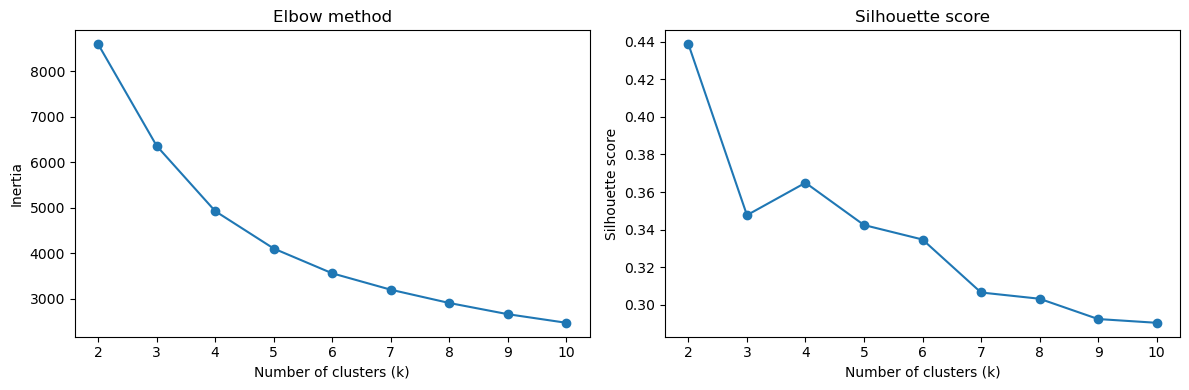

In [34]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(k_range, inertias, marker='o')
ax[0].set_xlabel('Number of clusters (k)'); ax[0].set_ylabel('Inertia')
ax[0].set_title('Elbow method')
ax[1].plot(k_range, silhouettes, marker='o')
ax[1].set_xlabel('Number of clusters (k)'); ax[1].set_ylabel('Silhouette score')
ax[1].set_title('Silhouette score')
plt.tight_layout()
plt.show()

In [35]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_file['cluster'] = kmeans.fit_predict(rfm_scaled)

profile = rfm_file.groupby('cluster').agg(
    recency_mean   = ('recency', 'mean'),
    frequency_mean = ('frequency', 'mean'),
    monetary_mean  = ('monetary', 'mean'),
    customers      = ('customer_id', 'count')
).round(1)

profile['pct_customers'] = (100 * profile['customers'] / profile['customers'].sum()).round(1)
profile['pct_revenue']   = (100 * rfm_file.groupby('cluster')['monetary'].sum()
                            / rfm_file['monetary'].sum()).round(1)
profile

,recency_mean,frequency_mean,monetary_mean,customers,pct_customers,pct_revenue
cluster,,,,,,
0,394.9,1.4,317.1,1973,33.6,3.6
1,28.3,3.1,857.5,1250,21.3,6.2
2,27.7,19.3,10731.2,1196,20.3,73.9
3,230.1,5.1,1948.5,1459,24.8,16.4


In [36]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_file['cluster'] = kmeans.fit_predict(rfm_scaled)

rfm_file['cluster'].value_counts()

cluster
0    1973
3    1459
1    1250
2    1196
Name: count, dtype: int64

In [37]:
profile = rfm_file.groupby('cluster').agg(
    recency_mean   = ('recency', 'mean'),
    frequency_mean = ('frequency', 'mean'),
    monetary_mean  = ('monetary', 'mean'),
    customers      = ('customer_id', 'count')
).round(1)

profile['pct_customers'] = (100 * profile['customers'] / profile['customers'].sum()).round(1)
profile['pct_revenue']   = (100 * rfm_file.groupby('cluster')['monetary'].sum()
                            / rfm_file['monetary'].sum()).round(1)

profile

,recency_mean,frequency_mean,monetary_mean,customers,pct_customers,pct_revenue
cluster,,,,,,
0,394.9,1.4,317.1,1973,33.6,3.6
1,28.3,3.1,857.5,1250,21.3,6.2
2,27.7,19.3,10731.2,1196,20.3,73.9
3,230.1,5.1,1948.5,1459,24.8,16.4


In [38]:
names = {
    0: 'Lost / One-time',
    1: 'New / Promising',
    2: 'Champions',
    3: 'At Risk'
}
rfm_file['segment'] = rfm_file['cluster'].map(names)

profile['segment'] = profile.index.map(names)
profile

,recency_mean,frequency_mean,monetary_mean,customers,pct_customers,pct_revenue,segment
cluster,,,,,,,
0,394.9,1.4,317.1,1973,33.6,3.6,Lost / One-time
1,28.3,3.1,857.5,1250,21.3,6.2,New / Promising
2,27.7,19.3,10731.2,1196,20.3,73.9,Champions
3,230.1,5.1,1948.5,1459,24.8,16.4,At Risk


In [39]:



'''Champions (20.3% of customers) generate 73.9% of revenue — a textbook Pareto concentration, surfaced from behavioural clustering rather than assumed.
At Risk customers (24.8%) still account for 16.4% of revenue, averaging £1,948 lifetime spend but no purchase in ~8 months — the highest-ROI retention target.
A third of customers are one-time buyers contributing just 3.6% of revenue, indicating a first-to-second purchase conversion problem.'''

'Champions (20.3% of customers) generate 73.9% of revenue — a textbook Pareto concentration, surfaced from behavioural clustering rather than assumed.\nAt Risk customers (24.8%) still account for 16.4% of revenue, averaging £1,948 lifetime spend but no purchase in ~8 months — the highest-ROI retention target.\nA third of customers are one-time buyers contributing just 3.6% of revenue, indicating a first-to-second purchase conversion problem.'

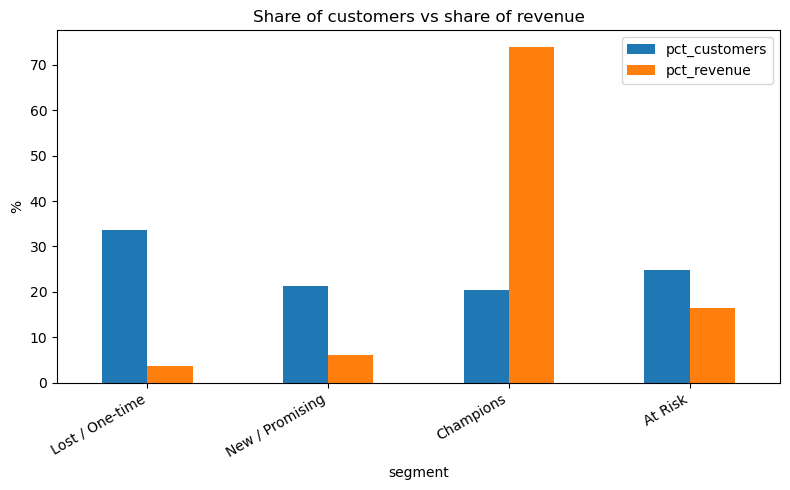

In [40]:
import os
os.makedirs('images', exist_ok=True)

# customers vs revenue by segment — the Pareto story in one image
profile.set_index('segment')[['pct_customers', 'pct_revenue']].plot(
    kind='bar', figsize=(8, 5))
plt.ylabel('%'); plt.title('Share of customers vs share of revenue')
plt.xticks(rotation=30, ha='right'); plt.tight_layout()
plt.savefig('images/customers_vs_revenue.png', dpi=150)
plt.show()